In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop, Adam


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

2024-10-13 15:43:11.148930: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-13 15:43:12.314208: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-13 15:43:14.955011: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-13 15:43:19.307548: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [ ]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [4]:



data = awgn(data, snr_range)

In [5]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)


# Example usage
max_shift = 2


# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)



In [6]:
data=augmented_sample

In [7]:
data.shape

(5000, 8192)

Generated CAZAC Preamble:
[ 1.        +0.00000000e+00j  0.87822157-4.78253979e-01j
  0.07473009-9.97203797e-01j -0.98883083-1.49042266e-01j
  0.27084047+9.62624247e-01j  0.36534102-9.30873749e-01j
 -0.5       +8.66025404e-01j  0.17364818-9.84807753e-01j
  0.6234898 +7.81831482e-01j -0.90096887+4.33883739e-01j
 -0.66168584-7.49781203e-01j  0.07473009-9.97203797e-01j
  0.36534102-9.30873749e-01j  0.17364818-9.84807753e-01j
 -0.5       -8.66025404e-01j -0.98883083+1.49042266e-01j
  0.27084047+9.62624247e-01j  0.6234898 -7.81831482e-01j
 -0.90096887+4.33883739e-01j  0.87822157-4.78253979e-01j
 -0.5       +8.66025404e-01j -0.5       -8.66025404e-01j
  0.87822157-4.78253979e-01j  0.82623877+5.63320058e-01j
  0.36534102+9.30873749e-01j  0.27084047+9.62624247e-01j
  0.6234898 +7.81831482e-01j  1.        +2.15587355e-14j
  0.17364818-9.84807753e-01j]


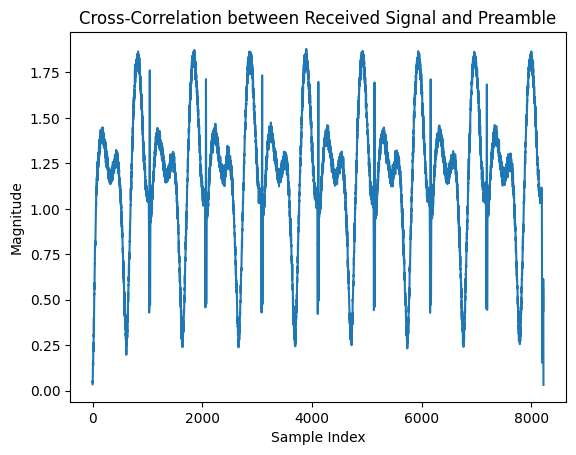

Detected preamble start at index: 3896
Entire detected preamble:
[-0.20016543-0.07364751j -0.17637549-0.11610521j -0.15166852-0.15691917j
 -0.10602194-0.18210134j -0.05164345-0.20564887j -0.01144501-0.21567972j
  0.04192137-0.20735175j  0.09538636-0.1946829j   0.13857612-0.17225873j
  0.17525044-0.12830958j  0.1957186 -0.08668505j  0.21435427-0.02554403j
  0.21121742+0.02491573j  0.19779361+0.07164046j  0.17670098+0.12745392j
  0.14934826+0.15533195j  0.10397593+0.19385031j  0.05001915+0.20640012j
 -0.00228843+0.21332512j -0.05520487+0.20634693j -0.11340747+0.18436092j
 -0.14370508+0.15073732j -0.18803431+0.10469333j -0.21485781+0.05315521j
 -0.20962843+0.00388744j -0.20863577-0.05577278j -0.18898531-0.10512002j
 -0.15041153-0.15057037j -0.11044615-0.18379914j]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate CAZAC (Zadoff-Chu) sequence
def generate_cazac(N, root):
    n = np.arange(29)  # Using 29 elements as per your setup
    cazac_seq = np.exp(-1j * np.pi * root * n * (n + 1) / N)
    
    # Print the generated preamble (CAZAC sequence)
    print("Generated CAZAC Preamble:")
    print(cazac_seq)
    
    return cazac_seq

# Cross-correlation function
def cross_correlation(received_signal, preamble):
    # Compute the cross-correlation between received signal and preamble
    preamble_conjugate = np.conj(preamble)  # Use the conjugate of the preamble
    correlation = np.correlate(received_signal, preamble_conjugate, mode='full')
    return correlation

# Your noisy RF dataset (replace 'data' with your actual dataset)
received_signal = data[0]  # Assuming data is a 2D array and you're using the first row

# Length of the CAZAC sequence
N = 63
root = 5  # Root of the Zadoff-Chu sequence

# Generate the CAZAC preamble sequence
cazac_preamble = generate_cazac(N, root)

# Perform cross-correlation between the received signal and preamble
correlation = cross_correlation(received_signal, cazac_preamble)

# Plot the correlation to detect the peak
plt.plot(np.abs(correlation))
plt.title('Cross-Correlation between Received Signal and Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Magnitude')
plt.show()

# Detect the peak position
peak_index = np.argmax(np.abs(correlation))
print(f"Detected preamble start at index: {peak_index}")

# Length of the preamble (same as the length of the CAZAC sequence)
preamble_length = len(cazac_preamble)

# Extract the detected preamble starting from peak_index
detected_preamble = received_signal[peak_index:peak_index + preamble_length]


# If you want to print the entire detected preamble
print("Entire detected preamble:")
print(detected_preamble)




In [8]:
preamble=detected_preamble
data_input=data

In [13]:
preamble

array([ 0.10611268,  0.09948081,  0.09275429,  0.08596456,  0.07907059,
        0.07215927,  0.06527611,  0.05848444,  0.05188464,  0.04519258,
        0.03849694,  0.03194584,  0.02564898,  0.01937716,  0.01311069,
        0.00685749,  0.00085813, -0.00504144, -0.01070186, -0.01633544,
       -0.02159419, -0.02673319, -0.03159221, -0.03622005, -0.04065218,
       -0.04522778, -0.04933592, -0.0533032 , -0.05701709])

In [ ]:
import numpy as np

# Assuming data_input is your input dataset and preamble is your synchronization preamble.

# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    # Compute the cross-correlation between the conjugate of the preamble and the current data row
    corr = np.correlate(data_input[i], np.conjugate(preamble), mode='full')
    
    # Find the peak index in the correlation result
    peak_index = np.argmax(corr)
    
    # Calculate synchronization offset
    sync_offset = peak_index - (len(preamble) - 1)  # Adjust to center the peak
    
    # Ensure the offset is valid
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = int(np.round(np.mean(sync_offsets)))  # Use the average to reduce outliers

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    
    for i in range(data_input.shape[0]):
        # Only synchronize if the offset is within the valid range
        if most_common_offset < data_input.shape[1]:  
            synchronized_data[i] = data_input[i, most_common_offset:]  # Keep data starting from the offset
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Handle edge case
    
    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    print("Synchronized data shape:", synchronized_data.shape)


Most Common Synchronization Offset: 3919
Synchronized data shape: (5000, 4273)


/tmp/ipykernel_4776/2965744305.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]  # Keep data starting from the offset


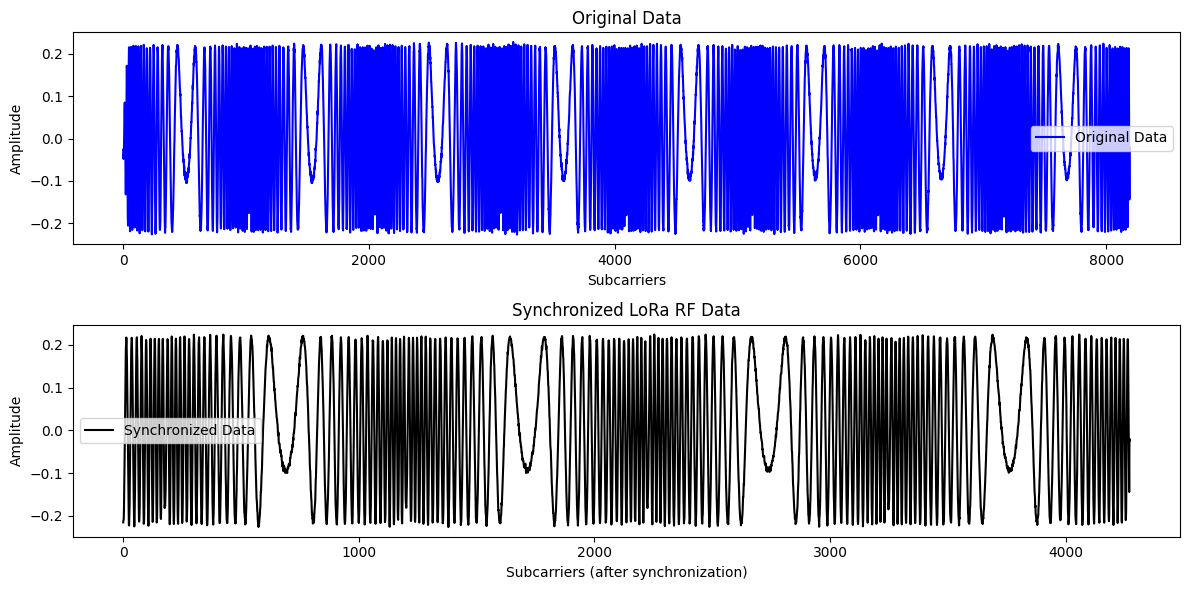

In [11]:
import matplotlib.pyplot as plt

# Plot original data and synchronized data for the first symbol
plt.figure(figsize=(12, 6))

# Original Data
plt.subplot(2, 1, 1)
plt.plot(data_input[0], label='Original Data', color='blue')
plt.title('Original Data')
plt.xlabel('Subcarriers')
plt.ylabel('Amplitude')
plt.legend()

# Synchronized Data
plt.subplot(2, 1, 2)
plt.plot(synchronized_data[0], label='Synchronized Data', color='black')
plt.title('Synchronized LoRa RF Data')
plt.xlabel('Subcarriers (after synchronization)')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
synchronized_data.shape

(5000, 4765)

In [12]:
data=synchronized_data

In [13]:
preamble=data[:512, :2]


In [15]:
import numpy as np

def coarse_cfo_estimation(preamble, symbol_length, B, Ts):
    """
    Perform coarse CFO compensation based on the provided preamble and parameters.

    Parameters:
    preamble (np.ndarray): Received baseband signal r[n], a 2D array representing the preamble.
    symbol_length (int): Length of the preamble.
    B (float): Bandwidth of the system.
    Ts (float): Sampling time period.

    Returns:
    compensated_signal (np.ndarray): Coarse CFO compensated signal r'[n].
    """

    # Step 1: Compute instantaneous frequency for each time index
    n = np.arange(symbol_length)
    f_n = -B/2 + (B/T)*Ts*n

    # Step 2: Estimate the coarse CFO (equation 10 from the image)

    delta_f_coarse = 1/symbol_length * np.sum(f_n)  # Estimated CFO
    avg_coarse = np.mean(delta_f_coarse)

    return avg_coarse


# Assuming you have the preamble as a numpy array and other parameters
#preamble = np.array([
      
   #    ])

preamble=preamble

symbol_length = 512
B = 125e3  # Example bandwidth for LoRa
Ts = 1 / 125e3  # Sampling period for LoRa devices
T=0.004096

avg_coarse= coarse_cfo_estimation(preamble, symbol_length, B, Ts)

r=data.shape[0]
# Step 3: Perform coarse frequency compensation (equation 12 from the image)
compensated_signal = data * np.exp(-2j * np.pi * avg_coarse * Ts *r )
print("Compensated Signal:")
print(compensated_signal)

# Resample the preamble and compensated signals for plotting
#resample_factor = 5  # Adjust this value as needed
#preamble_resampled = preamble[::resample_factor]
#compensated_signal_resampled = compensated_signal[::resample_factor]





("Estimated Coarse Frequency Offset (Delta f_coarse):", avg_coarse)


Compensated Signal:
[[-0.15919914+0.14428969j -0.15532442+0.14077785j -0.15458891+0.14011122j
  ... -0.10662348+0.09663789j -0.01455908+0.01319558j
  -0.01747748+0.01584066j]
 [-0.12115037+0.10980429j -0.09264425+0.08396785j -0.0568337 +0.05151106j
  ... -0.1598054 +0.14483917j  0.00329627-0.00298756j
   0.00046719-0.00042344j]
 [ 0.06853685-0.06211818j  0.10391178-0.09418015j  0.13009906-0.11791491j
  ... -0.0303569 +0.02751389j  0.01968759-0.0178438j
   0.02051253-0.01859147j]
 ...
 [-0.07182471+0.06509813j  0.02728552-0.02473015j  0.12398374-0.11237231j
  ... -0.31598583+0.28639287j  0.04175048-0.03784043j
   0.04231731-0.03835417j]
 [-0.33322978+0.30202187j -0.27590725+0.25006776j -0.19438988+0.17618471j
  ... -0.37467349+0.33958426j  0.00289643-0.00262517j
  -0.00584618+0.00529867j]
 [ 0.38873318-0.35232721j  0.36772661-0.33328797j  0.32071361-0.29067787j
  ...  0.28776458-0.26081461j  0.02365155-0.02143652j
   0.03740461-0.03390156j]]


('Estimated Coarse Frequency Offset (Delta f_coarse):', -122.0703125)

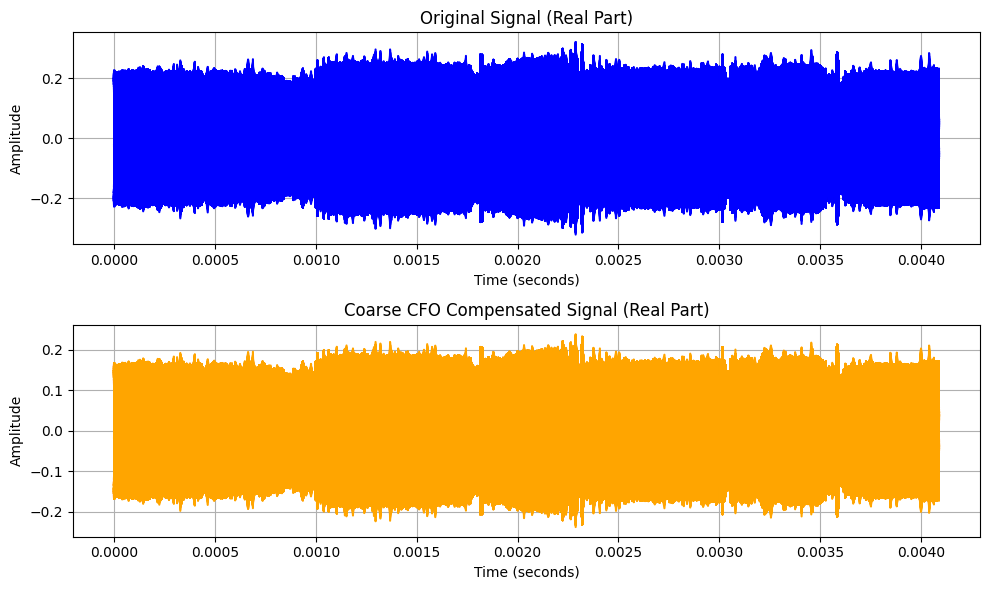

In [16]:


# Step 3: Plot the real (original) data and compensated data
# Extract real parts for visualization purposes
real_original_data = np.real(data[:512])

real_compensated_data = np.real(compensated_signal[:512])


# Create a time axis for plotting (optional, based on the length of your data)
#time = np.arange(data.shape[0]) * Ts
#time = 512 * Ts
time = np.arange(512) * Ts
# Plotting
plt.figure(figsize=(10, 6))

# Plot original signal
plt.subplot(2, 1, 1)
plt.plot(time, real_original_data, label="Original Data", color='blue')
plt.title("Original Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot compensated signal
plt.subplot(2, 1, 2)
plt.plot(time, real_compensated_data, label="Coarse CFO Compensated Data", color='orange')
plt.title("Coarse CFO Compensated Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()




In [36]:
compensated_signal.shape

(5000, 4779)

In [16]:
data2=compensated_signal

In [18]:
import numpy as np

# Constants for LoRa
Fs = 125e3  # Sampling frequency for LoRa (125 kHz example)
SF = 9  # Example spreading factor
num_samples_per_symbol = 2**SF  # LoRa symbol length depends on Spreading Factor
num_symbols = data2.shape[0]  # Number of LoRa symbols in your dataset (5000)

# Step 1: Define subcarrier indices where the preamble pilots will be inserted
subcarrier_indices = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 100, 200, 300, 400, 500, 800, 1300,1800,2500,3000,3500,4000,4100 ]  # Example locations, adjust based on your design

# Step 2: Insert preamble as pilot sequence into specific subcarriers
preamble = data2[:512, :2]  # Example preamble
preamble_resized = np.resize(preamble[:, 0], (num_symbols,))  # Resize preamble to match the number of symbols

# Insert the resized preamble into specified subcarriers
for idx in subcarrier_indices:
    data2[:, idx] = preamble_resized  # Insert the resized preamble as pilots

# Step 3: Conjugate the preamble for CFO estimation
preamble_conjugate = np.conjugate(preamble_resized)

# Step 4: Estimate CFO using pilots (inserted preamble)
cfo_estimates = []
for i in range(num_symbols):
    loRa_symbol_flat = data2[i].flatten()
    
    # Cross-correlation between the symbol and conjugate of the pilot sequence (preamble)
    corr = np.correlate(loRa_symbol_flat, preamble_conjugate, mode='full')
    
    # Find the peak of the cross-correlation
    peak_idx = np.argmax(np.abs(corr))
    peak_val = corr[peak_idx]
    
    # Extract phase difference and estimate CFO
    phase_diff = np.angle(peak_val)
    cfo_estimate = phase_diff * -Fs / (2 *512* np.pi)
    cfo_estimates.append(cfo_estimate)

# Step 5: Average CFO estimate
avg_cfo = np.mean(cfo_estimates)
print(f"Estimated CFO: {avg_cfo:.2f} Hz")

# Step 6: Fine CFO Compensation with Pilot Sequences
# Step 6: Fine CFO Compensation with Pilot Sequences
for iteration in range(10):  # Iteratively refine until offset is less than 1 Hz
    p = data2.shape[0]  # Number of symbols
    Ts = 1 / Fs  # Sampling period

    # Apply phase correction using the estimated CFO
    compensated_data2 = data2 * np.exp(-2j * np.pi * avg_cfo * Ts * np.arange(data2.shape[1]))

    # Re-estimate CFO from compensated data
    new_cfo_estimates = []
    for i in range(num_symbols):
        loRa_symbol_flat = compensated_data2[i].flatten()
        corr = np.correlate(loRa_symbol_flat, preamble_conjugate, mode='full')
        peak_idx = np.argmax(np.abs(corr))
        
        # Set a threshold for peak detection
        threshold = 0.1 * np.max(np.abs(corr))  # Example threshold
        if np.abs(corr[peak_idx]) < threshold:
            new_cfo_estimate = 0  # Or handle as needed
        else:
            phase_diff = np.angle(corr[peak_idx])
            new_cfo_estimate = phase_diff * -Fs / (2 * 512 * np.pi)
        
        new_cfo_estimates.append(new_cfo_estimate)

    avg_cfo = np.mean(new_cfo_estimates)
    print(f"Iteration {iteration + 1}: Fine CFO: {avg_cfo:.2f} Hz")

    if abs(avg_cfo) < 1:  # More stringent convergence criterion
        break


Estimated CFO: -3.28 Hz
Iteration 1: Fine CFO: -16.97 Hz
Iteration 2: Fine CFO: 44.27 Hz
Iteration 3: Fine CFO: -15.06 Hz
Iteration 4: Fine CFO: 22.62 Hz
Iteration 5: Fine CFO: 11.17 Hz
Iteration 6: Fine CFO: 43.53 Hz
Iteration 7: Fine CFO: -15.38 Hz
Iteration 8: Fine CFO: 21.64 Hz
Iteration 9: Fine CFO: -0.32 Hz


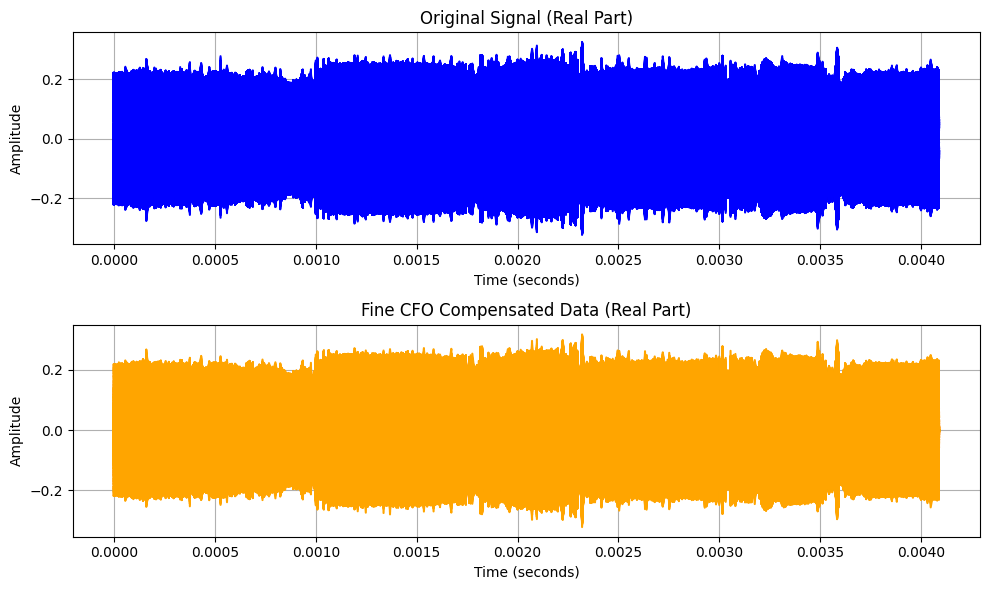

In [19]:


# Step 3: Plot the real (original) data and compensated data
# Extract real parts for visualization purposes
real_original_data = np.real(augmented_sample[:512])

real_compensated_data = np.real(compensated_data2[:512])


# Create a time axis for plotting (optional, based on the length of your data)
#time = np.arange(data.shape[0]) * Ts
#time = 512 * Ts
time = np.arange(512) * Ts
# Plotting
plt.figure(figsize=(10, 6))

# Plot original signal
plt.subplot(2, 1, 1)
plt.plot(time, real_original_data, label="Original Data", color='blue')
plt.title("Original Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot compensated signal
plt.subplot(2, 1, 2)
plt.plot(time, real_compensated_data, label="Fine CFO Compensated Data", color='orange')
plt.title("Fine CFO Compensated Data (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()




In [21]:
data3=compensated_data2

In [33]:
data3.shape

(5000, 4765)

In [ ]:
from scipy.interpolate import interp1d
import numpy as np

# Constants for LoRa
Fs = 125e3  # Sampling frequency for LoRa (125 kHz example)
SF = 9  # Example spreading factor, adjust according to your LoRa system
N_fft = 4096  # FFT size (you may adjust this based on your requirements)

# Detected preamble (this serves as your known sequence)
preamble = data3[:512, :2]  # Example preamble (512 samples from the dataset)

# Assuming 'data' is your synchronized dataset (each row is a LoRa symbol)
data = data3  # After CFO compensation

# System parameters
num_ofdm_symbols = data.shape[0]  # Number of LoRa symbols in your dataset
SNR =-20  # Example SNR value
signal_power = np.mean(np.abs(data)**2)  # Estimated signal power (E_s)
noise_variance = signal_power / SNR  # Assumed noise variance (sigma^2)

# Step 1: Define subcarrier indices where preamble pilots will be inserted
subcarrier_indices = [2, 5, 9, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200, 300, 400, 700, 1000, 2000, 3000, 4000, 4100]  # Example locations for pilots

# Step 2: Insert preamble as pilot sequences into specific subcarriers
# Reshape the preamble to match the number of pilot subcarriers and symbols
preamble_resized = np.resize(preamble[:, 0], (num_ofdm_symbols, len(subcarrier_indices)))  # Resize to match symbols and subcarriers

for idx, sc_idx in enumerate(subcarrier_indices):
    data[:, sc_idx] = preamble_resized[:, idx]  # Insert the preamble as pilots into the specified subcarriers

# Step 3: Extract the received preamble for channel estimation
preamble_received = data[:, subcarrier_indices]  # Extract the symbols from subcarrier indices for pilots

# Step 4: Realistic MMSE Channel Estimation with Correlation Matrix
def generate_toeplitz_matrix(size, decay_factor):
    """Generates a Toeplitz matrix to model channel correlation."""
    return np.fromfunction(lambda i, j: decay_factor ** np.abs(i - j), (size, size))

def mmse_channel_estimation(preamble_received, known_preamble, beta, SNR, decay_factor):
    # LS estimation (now both have the same shape)
    H_ls = preamble_received / known_preamble  
    
    # Generate realistic R_hh using Toeplitz matrix to model channel correlation
    R_hh = generate_toeplitz_matrix(known_preamble.shape[1], decay_factor)  
    
    # Regularization term
    reg_term = (beta / SNR) * np.eye(known_preamble.shape[1])  
    
    # Calculate the MMSE estimation for each symbol
    H_mmse = np.zeros_like(H_ls, dtype=complex)  # Prepare array for MMSE estimates
    for i in range(H_ls.shape[0]):  # Loop over each symbol
        H_mmse[i] = R_hh @ np.linalg.inv(R_hh + reg_term) @ H_ls[i]  # Ensure we multiply correctly
    return H_mmse

# Perform MMSE channel estimation at preamble positions
beta = 1.0  # Regularization parameter
decay_factor = 0.6  # Example decay factor for correlation matrix
H_preamble_mmse = mmse_channel_estimation(preamble_received, preamble_resized, beta, SNR, decay_factor)

# Step 5: Interpolate the channel estimates across all subcarriers
def interpolate_channel(H_preamble, N_fft):
    H_estimated = np.zeros((num_ofdm_symbols, N_fft), dtype=complex)
    for i in range(num_ofdm_symbols):
        interp_fn = interp1d(np.arange(len(subcarrier_indices)), H_preamble[i, :], kind='linear', fill_value="extrapolate")
        H_estimated[i, :] = interp_fn(np.arange(N_fft))  # Interpolate across subcarriers
    return H_estimated

# Interpolate to estimate the channel over all subcarriers
H_estimated = interpolate_channel(H_preamble_mmse, N_fft)

# Step 6: MMSE Equalization based on channel estimates
def mmse_equalization(data, H_estimated, noise_variance, signal_power):
    W_mmse = np.conj(H_estimated) / (np.abs(H_estimated)**2 + (noise_variance / signal_power))
    equalized_data = np.zeros_like(data, dtype=complex)
    for i in range(data.shape[0]):
        equalized_data[i, :H_estimated.shape[1]] = data[i, :H_estimated.shape[1]] * W_mmse[i]  # Apply MMSE weights
    return equalized_data

# Apply MMSE equalization to the received data
equalized_data = mmse_equalization(data, H_estimated, noise_variance, signal_power)

# Now, 'equalized_data' contains the MMSE equalized symbols across all LoRa symbols
print("Equalized Data:\n", equalized_data)


Equalized Data:
 [[ 0.13804748-0.12511894j  0.10850356-0.09855706j  0.1411397 -0.12792156j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.00632159-0.00572955j -0.04125619+0.03747424j -0.16734628+0.15167382j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [-0.15662626+0.14195777j -0.16555851+0.15038179j -0.15959764+0.14465087j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 ...
 [-0.24359197+0.22077889j -0.33044993+0.30015764j -0.16720711+0.15154769j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.06546859-0.05933727j -0.04477478+0.04067028j -0.15690651+0.14221177j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [-0.23473852+0.2127546j  -0.14271619+0.12963342j  0.14423252-0.13072473j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


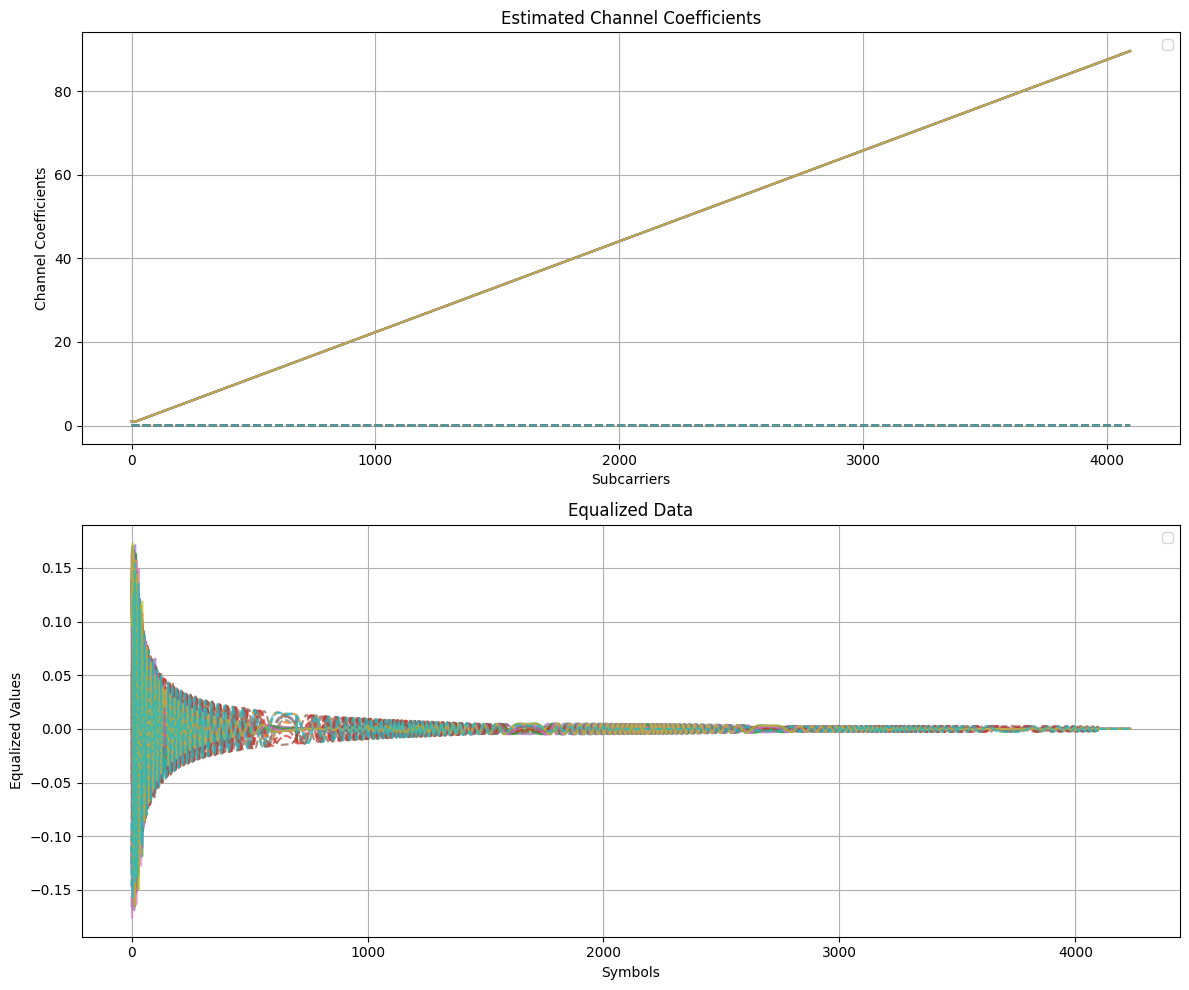

In [ ]:
import matplotlib.pyplot as plt

def plot_channel_and_equalized_data(H_estimated, equalized_data, num_symbols_to_plot=10):
    # Set up the figure and axes for the plots
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot the estimated channel
    for i in range(min(num_symbols_to_plot, H_estimated.shape[0])):  # Limit the number of symbols to plot
        axs[0].plot(np.real(H_estimated[i, :]), alpha=0.7)
        axs[0].plot(np.imag(H_estimated[i, :]), linestyle='--', alpha=0.7)
    
    axs[0].set_title('Estimated Channel Coefficients')
    axs[0].set_xlabel('Subcarriers')
    axs[0].set_ylabel('Channel Coefficients')
    axs[0].grid()
    axs[0].legend()
    
    # Plot the equalized data
    for i in range(min(num_symbols_to_plot, equalized_data.shape[0])):  # Limit the number of symbols to plot
        axs[1].plot(np.real(equalized_data[i, :]), alpha=0.7)
        axs[1].plot(np.imag(equalized_data[i, :]), linestyle='--', alpha=0.7)
    
    axs[1].set_title('Equalized Data')
    axs[1].set_xlabel('Symbols')
    axs[1].set_ylabel('Equalized Values')
    axs[1].grid()
    axs[1].legend()

    # Show the plots
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_channel_and_equalized_data(H_estimated, equalized_data)


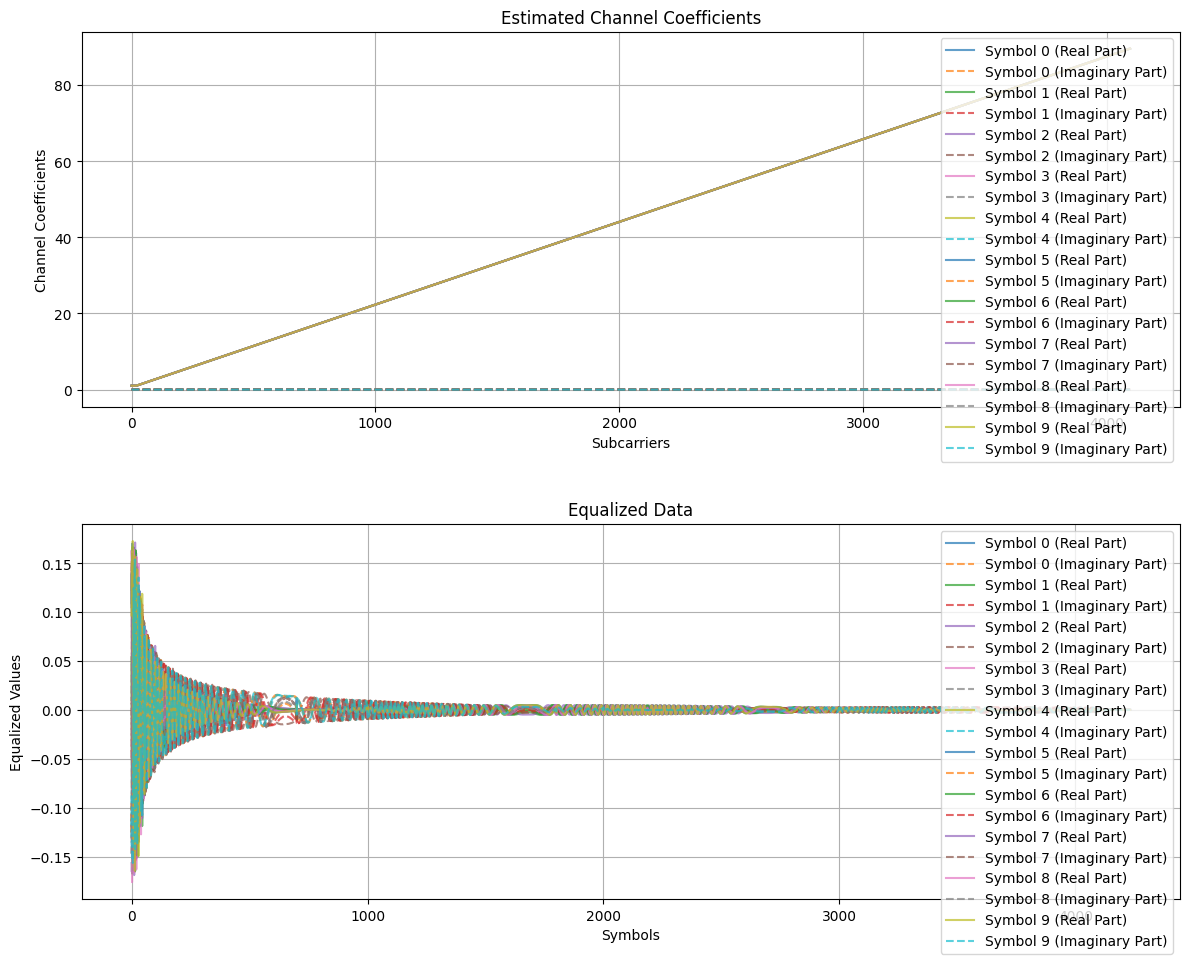

In [ ]:
import matplotlib.pyplot as plt

def plot_channel_and_equalized_data(H_estimated, equalized_data, num_symbols_to_plot=10):
    # Set up the figure and axes for the plots
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot the estimated channel
    for i in range(min(num_symbols_to_plot, H_estimated.shape[0])):  # Limit the number of symbols to plot
        axs[0].plot(np.real(H_estimated[i, :]), label=f'Symbol {i} (Real Part)', alpha=0.7)
        axs[0].plot(np.imag(H_estimated[i, :]), label=f'Symbol {i} (Imaginary Part)', linestyle='--', alpha=0.7)
    
    axs[0].set_title('Estimated Channel Coefficients')
    axs[0].set_xlabel('Subcarriers')
    axs[0].set_ylabel('Channel Coefficients')
    axs[0].grid()
    axs[0].legend()
    
    # Plot the equalized data
    for i in range(min(num_symbols_to_plot, equalized_data.shape[0])):  # Limit the number of symbols to plot
        axs[1].plot(np.real(equalized_data[i, :]), label=f'Symbol {i} (Real Part)', alpha=0.7)
        axs[1].plot(np.imag(equalized_data[i, :]), label=f'Symbol {i} (Imaginary Part)', linestyle='--', alpha=0.7)
    
    axs[1].set_title('Equalized Data')
    axs[1].set_xlabel('Symbols')
    axs[1].set_ylabel('Equalized Values')
    axs[1].grid()
    axs[1].legend()

    # Show the plots
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_channel_and_equalized_data(H_estimated, equalized_data)


In [25]:
data=equalized_data

In [26]:
def normalize_data(data):
    rms = np.sqrt(np.mean(np.abs(data)**2))
    return data / rms
normalized_data = normalize_data(data)

In [27]:
data=normalized_data

In [28]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(data)
imaginary_part = np.imag(data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0],data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [38]:
data_real_values.shape

(5000, 4809, 2)

In [85]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [29]:
input_data=data_real_values

In [30]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [31]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

In [32]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)






In [33]:


# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)




In [34]:
# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx)




In [35]:


# Reshape data for LSTM input (samples, timesteps, features)
n_samples, n_timesteps, n_features = data_spectrogram.shape

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)


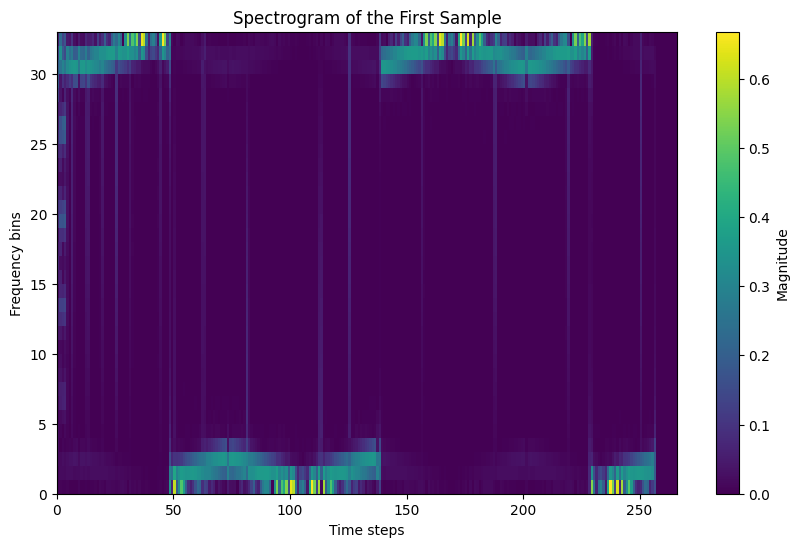

In [36]:
# Plot the spectrogram for the first sample in the training data
plt.figure(figsize=(10, 6))
plt.pcolormesh(np.abs(data_spectrogram[0]), cmap='viridis')
plt.title('Spectrogram of the First Sample')
plt.ylabel('Frequency bins')
plt.xlabel('Time steps')
plt.colorbar(label='Magnitude')
plt.show()

In [ ]:

import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Assuming normalized_data is your input data and label is the corresponding labels

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assuming normalized_data is your input data and label is the corresponding labels

# Flatten the data if necessary (make sure it's 2D: samples, features)
data_train = data_train.reshape((data_train.shape[0], -1))  # Flattening to (samples, features)
data_test = data_test.reshape((data_test.shape[0], -1))  # Flattening to (samples, features)

# Train the XGBoost classifier
clf = XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=20, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, '514_xgboost_model.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot ROC curves (for multi-class classification)
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(data_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


Accuracy: 97.00%
Precision: 97.06%
Recall: 97.00%
F1 Score: 97.00%


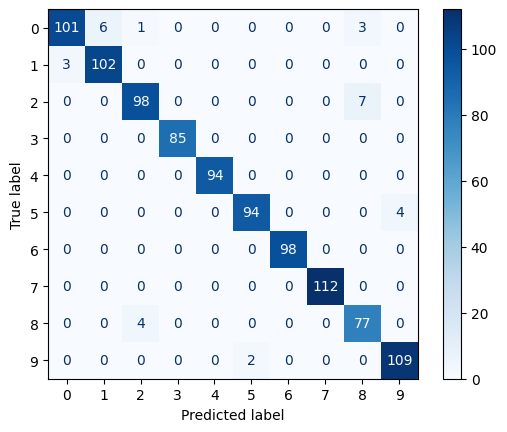

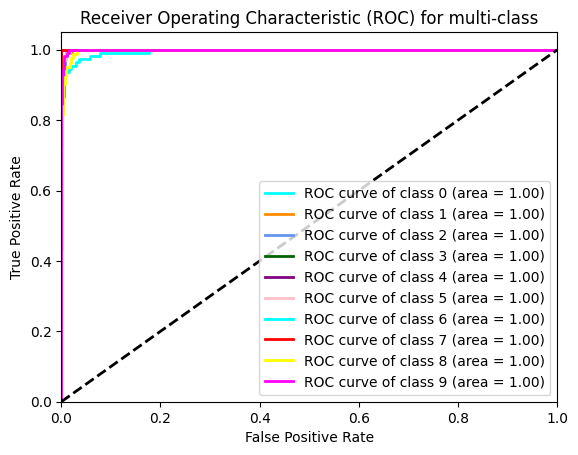

Class 0 AUC: 1.00
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [45]:

import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Assuming normalized_data is your input data and label is the corresponding labels

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assuming normalized_data is your input data and label is the corresponding labels

# Flatten the data if necessary (make sure it's 2D: samples, features)
data_train = data_train.reshape((data_train.shape[0], -1))  # Flattening to (samples, features)
data_test = data_test.reshape((data_test.shape[0], -1))  # Flattening to (samples, features)

# Train the XGBoost classifier
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, '314_xgboost_model.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot ROC curves (for multi-class classification)
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(data_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


Accuracy: 97.00%
Precision: 97.06%
Recall: 97.00%
F1 Score: 97.00%


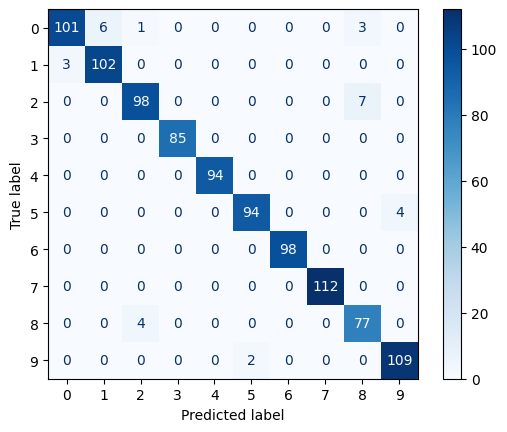

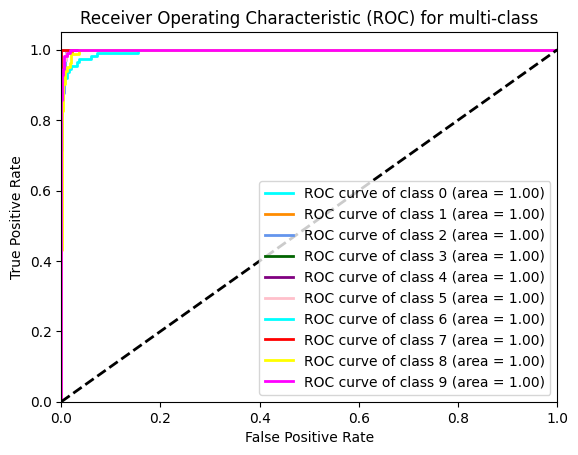

Class 0 AUC: 1.00
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [73]:

import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Assuming normalized_data is your input data and label is the corresponding labels

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assuming normalized_data is your input data and label is the corresponding labels

# Flatten the data if necessary (make sure it's 2D: samples, features)
data_train = data_train.reshape((data_train.shape[0], -1))  # Flattening to (samples, features)
data_test = data_test.reshape((data_test.shape[0], -1))  # Flattening to (samples, features)

# Train the XGBoost classifier
clf = XGBClassifier(n_estimators=1000, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, '814_xgboost_model.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot ROC curves (for multi-class classification)
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(data_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 96.00%
Precision: 96.23%
Recall: 96.00%
F1 Score: 95.98%


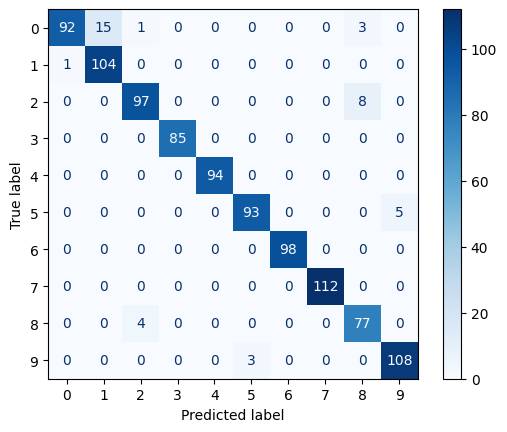

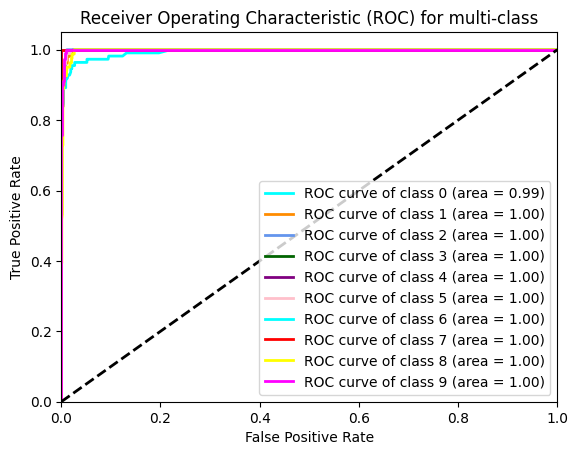

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [56]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier  # Import RandomForestClassifier
import matplotlib.pyplot as plt


# Assuming normalized_data is your input data and label is the corresponding labels

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)




# Assuming normalized_data is your input data and label is the corresponding labels

# Flatten the data if necessary (make sure it's 2D: samples, features)
data_train = data_train.reshape((data_train.shape[0], -1))  # Flattening to (samples, features)
data_test = data_test.reshape((data_test.shape[0], -1))  # Flattening to (samples, features)

# Train the XGBoost classifier
clf = RandomForestClassifier(n_estimators=500, max_depth=100, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, 'AB_481_xgboost_model.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot ROC curves (for multi-class classification)
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(data_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 96.00%
Precision: 96.23%
Recall: 96.00%
F1 Score: 95.98%


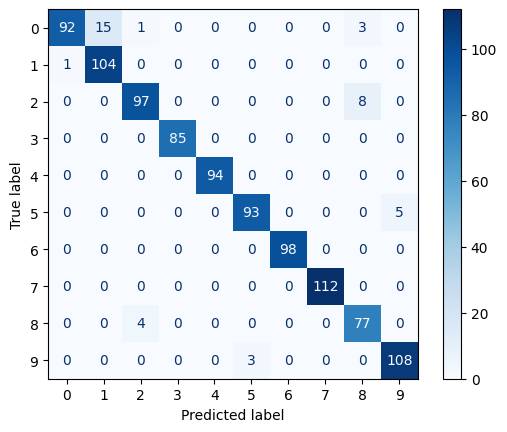

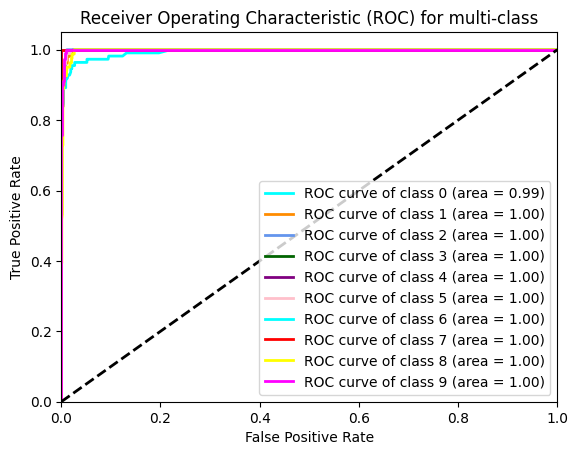

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [54]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier  # Import RandomForestClassifier
import matplotlib.pyplot as plt


# Assuming normalized_data is your input data and label is the corresponding labels

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)




# Assuming normalized_data is your input data and label is the corresponding labels

# Flatten the data if necessary (make sure it's 2D: samples, features)
data_train = data_train.reshape((data_train.shape[0], -1))  # Flattening to (samples, features)
data_test = data_test.reshape((data_test.shape[0], -1))  # Flattening to (samples, features)

# Train the XGBoost classifier
clf = RandomForestClassifier(n_estimators=500, max_depth=200, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, '481_xgboost_model.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot ROC curves (for multi-class classification)
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(data_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


In [49]:
data_spectrogram.shape

(5000, 33, 302)

In [57]:


# Reshape data for LSTM input (samples, timesteps, features)
n_samples, n_timesteps, n_features = data_spectrogram.shape

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)


In [ ]:
from keras.layers import BatchNormalization


model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.3))  # Slightly lower dropout
model.add(Bidirectional(LSTM(128)))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming 10-class classification


# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=350, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('AGG1_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'AGG1_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

In [ ]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=650, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('GG1_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'GG1_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 92.60%
Precision: 92.62%
Recall: 92.60%
F1 Score: 92.60%


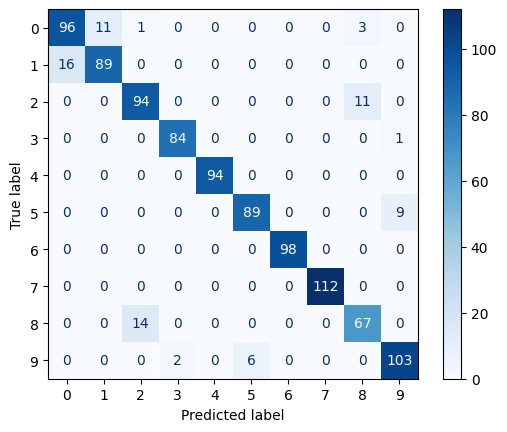

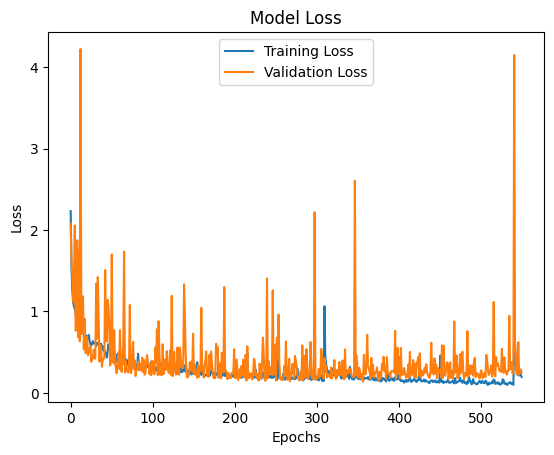

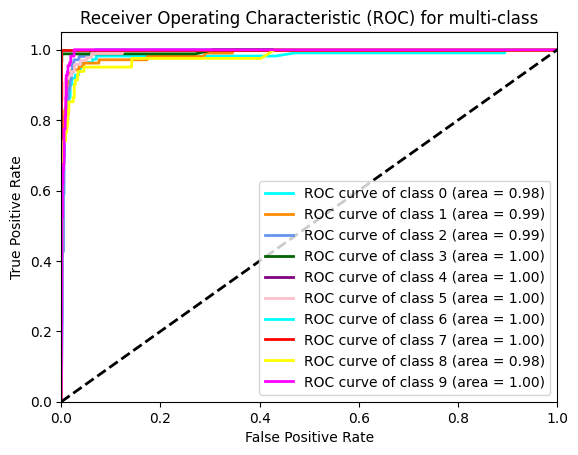

Class 0 AUC: 0.98
Class 1 AUC: 0.99
Class 2 AUC: 0.99
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.98
Class 9 AUC: 1.00


In [82]:
### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.01, max_depth=100, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'ACC14_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import joblib

# Train the Support Vector Machine classifier on the extracted features
clf = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
clf.fit(features_train, label_train)

# Save the SVM model
joblib.dump(clf, 'CC145_svm_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ROC and AUC calculations for SVM
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import joblib

# Train the RandomForest classifier on the extracted features
clf = RandomForestClassifier(n_estimators=500, max_depth=20, random_state=42, bootstrap=True, oob_score=True)
clf.fit(features_train, label_train)

# Save the RandomForest model
joblib.dump(clf, 'CC143_randomforest_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ROC and AUC calculations for RandomForest
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import joblib

# Train the RandomForest classifier on the extracted features
clf = RandomForestClassifier(n_estimators=500, max_depth=100, random_state=42)
clf.fit(features_train, label_train)

# Save the RandomForest model
joblib.dump(clf, 'DD_randomforest_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function (RandomForest does not have training history, so this part can be skipped)

# ROC and AUC calculations for RandomForest
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


/home/codespace/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/codespace/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Accuracy: 92.50%
Precision: 92.57%
Recall: 92.50%
F1 Score: 92.48%


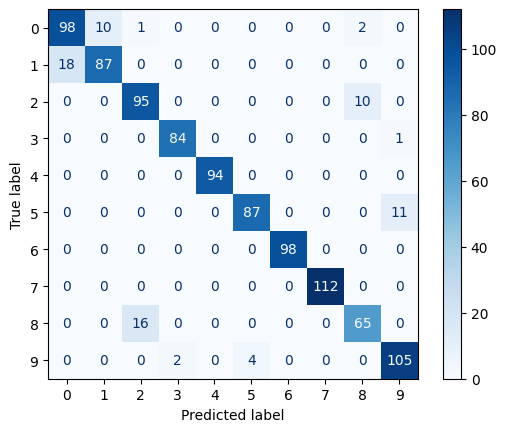

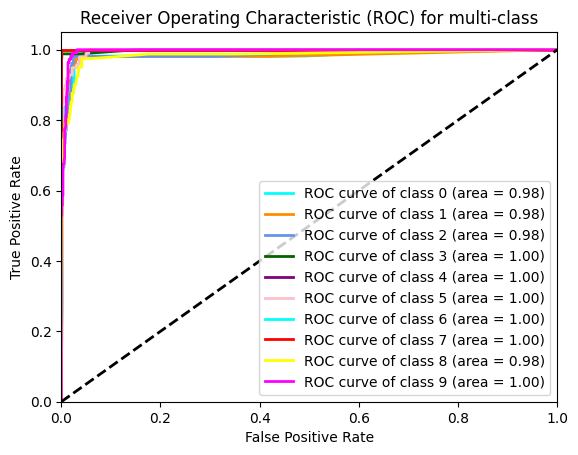

Class 0 AUC: 0.98
Class 1 AUC: 0.98
Class 2 AUC: 0.98
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.98
Class 9 AUC: 1.00


In [85]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
import matplotlib.pyplot as plt

# Define base models
estimators = [
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42))
]

# Create the stacking classifier
clf = StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier(n_estimators=500, max_depth=50))

# Train the StackingClassifier
clf.fit(features_train, label_train)

# Save the Stacking model
joblib.dump(clf, 'stacked_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ROC curve, AUC calculation, and plotting as before...
# Plot the loss function (RandomForest does not have training history, so this part can be skipped)

# ROC and AUC calculations for RandomForest
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


Epoch 1/450


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.1787 - loss: 2.3463 - val_accuracy: 0.1138 - val_loss: 2.2147
Epoch 2/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4139 - loss: 1.3822 - val_accuracy: 0.3738 - val_loss: 1.4557
Epoch 3/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4558 - loss: 1.1979 - val_accuracy: 0.4412 - val_loss: 1.0782
Epoch 4/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4797 - loss: 1.0760 - val_accuracy: 0.5950 - val_loss: 0.7969
Epoch 5/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5418 - loss: 0.9211 - val_accuracy: 0.3025 - val_loss: 2.7995
Epoch 6/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5514 - loss: 0.9019 - val_accuracy: 0.4800 - val_loss: 1.1283
Epoch 7/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5485 - loss: 0.8729 - val_accuracy: 0.6250 - val_loss: 0.8096
Epoch 8/450
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5616 - loss: 0.8710 - val_accuracy

Accuracy: 92.50%
Precision: 92.62%
Recall: 92.50%
F1 Score: 92.53%


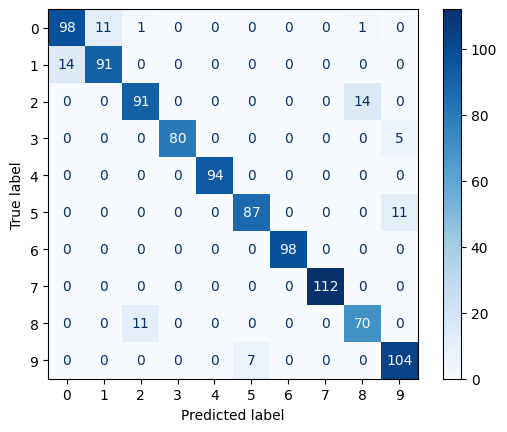

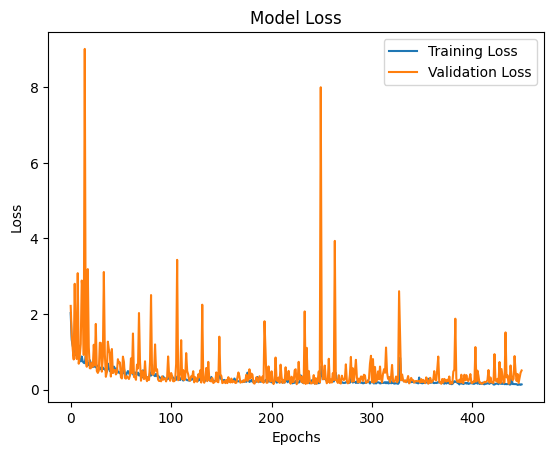

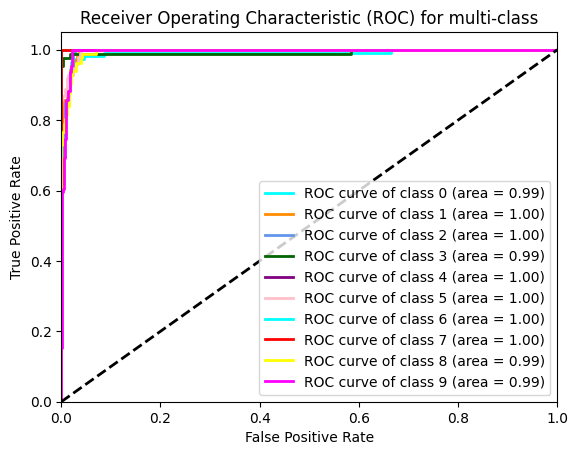

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 0.99
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.99
Class 9 AUC: 0.99


In [60]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=450, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('ABB0116_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'ABB0116_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 92.10%
Precision: 92.21%
Recall: 92.10%
F1 Score: 92.13%


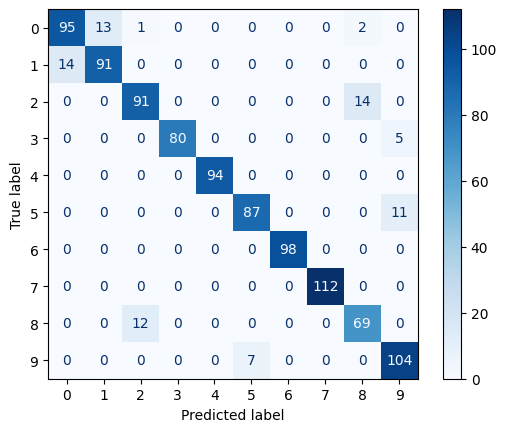

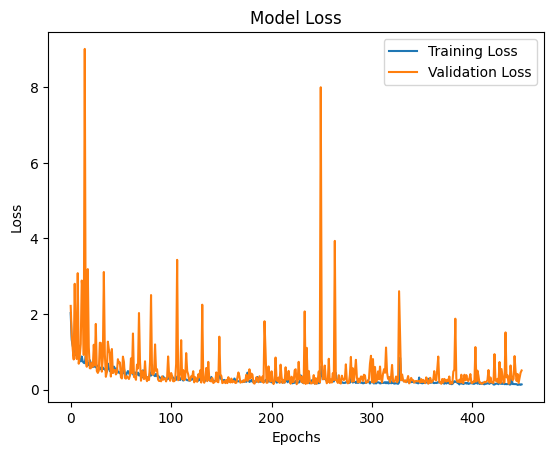

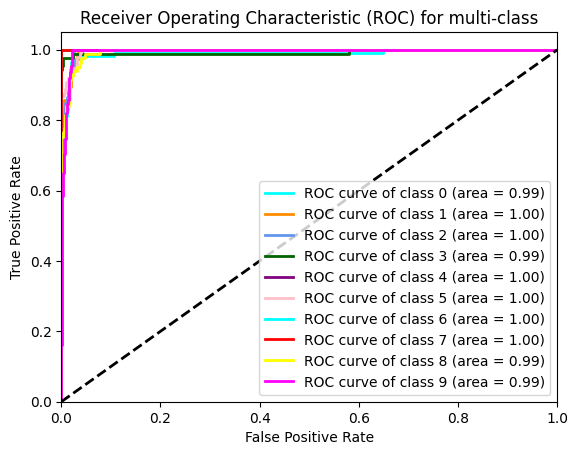

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 0.99
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.99
Class 9 AUC: 0.99


In [62]:
### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'ABC16_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 93.90%
Precision: 94.11%
Recall: 93.90%
F1 Score: 93.92%


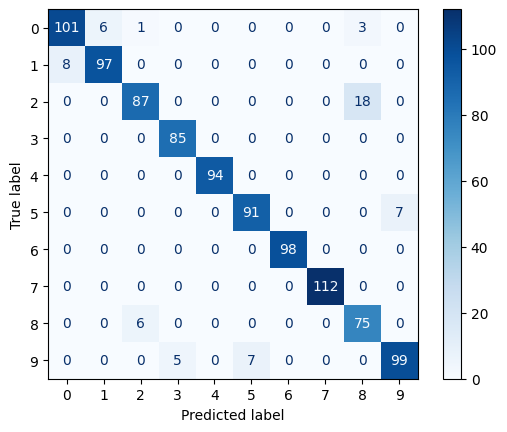

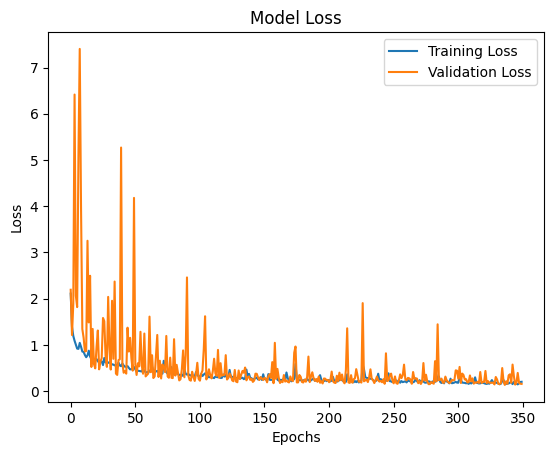

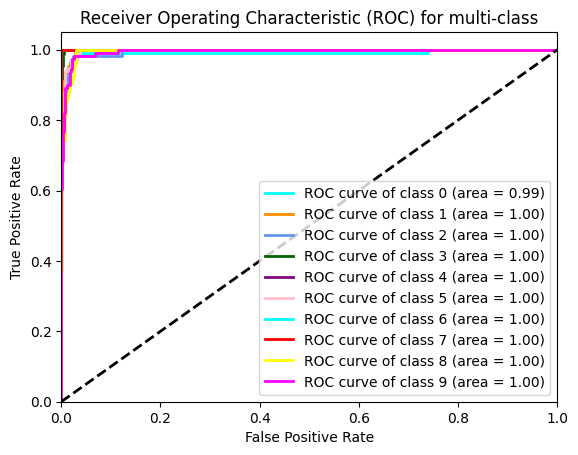

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [46]:
### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'BBA0116_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

In [84]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
Bilstm_model = Sequential()
Bilstm_model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.5))
Bilstm_model.add(Bidirectional(LSTM(64)))
Bilstm_model.add(Dense(64, activation='relu'))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.5))
Bilstm_model.add(Dense(32, activation='relu'))

Bilstm_model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
Bilstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = Bilstm_model.fit(data_train, label_train, epochs=400, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(Bilstm_model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('AB1_XGBoost_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = RandomForestClassifier(n_estimators=200, max_depth=200, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'AB1_Random_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Epoch 1/400


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 8943), dtype=float32). Expected shape (None, 33, 271), but input has incompatible shape (32, 8943)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 8943), dtype=float32)
  • training=True
  • mask=None

Accuracy: 93.40%
Precision: 93.51%
Recall: 93.40%
F1 Score: 93.42%


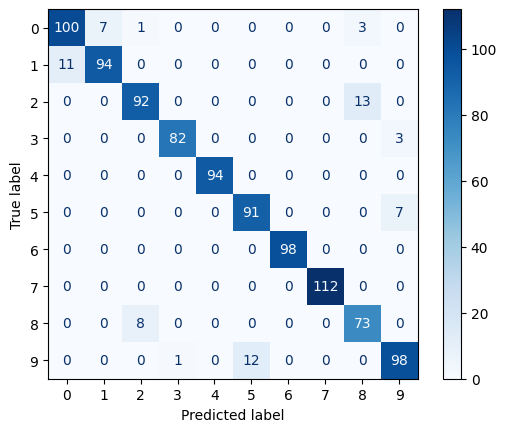

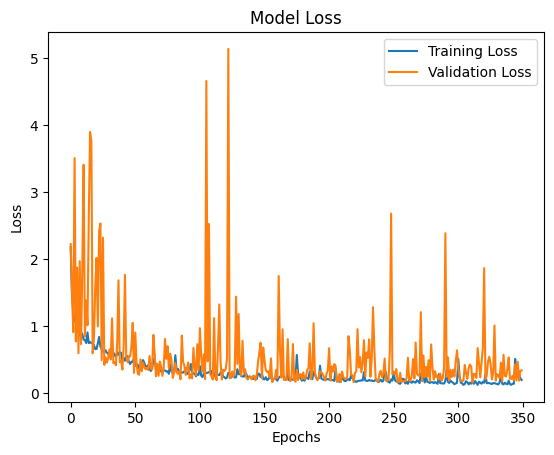

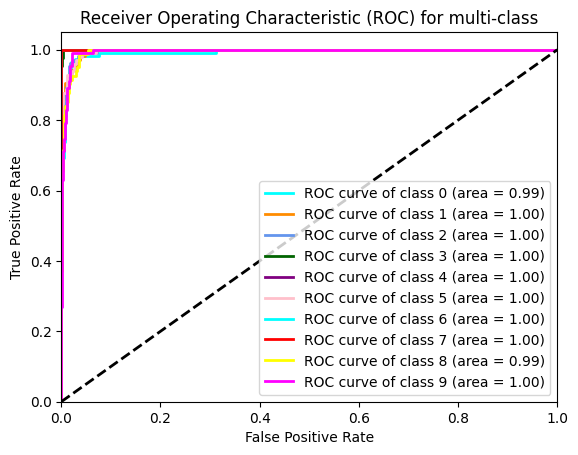

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.99
Class 9 AUC: 1.00


In [67]:

# Save the BiLSTM feature extractor model
#model_feature_extractor.save('B006_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=1, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'B2106_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300


2024-10-12 05:44:13.579899: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 114470400 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.1632 - loss: 2.5034 - val_accuracy: 0.1138 - val_loss: 2.2224
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3086 - loss: 1.5925 - val_accuracy: 0.4325 - val_loss: 1.2873
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4243 - loss: 1.2379 - val_accuracy: 0.2713 - val_loss: 1.3169
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4721 - loss: 1.0986 - val_accuracy: 0.1462 - val_loss: 3.6600
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4924 - loss: 1.0379 - val_accuracy: 0.2713 - val_loss: 1.9438
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5460 - loss: 0.9249 - val_accuracy: 0.3150 - val_loss: 1.6174
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5412 - loss: 0.9227 - val_accuracy: 0.4675 - val_loss: 0.9312
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5552 - loss: 0.9116 - val_accuracy

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5319 - loss: 0.9470 - val_accuracy: 0.4725 - val_loss: 0.8795
Epoch 10/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5751 - loss: 0.8727 - val_accuracy: 0.1737 - val_loss: 3.4527
Epoch 11/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5487 - loss: 0.9264 - val_accuracy: 0.6025 - val_loss: 0.9524
Epoch 12/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5710 - loss: 0.8374 - val_accuracy: 0.4550 - val_loss: 0.8706
Epoch 13/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5330 - loss: 0.9373 - val_accuracy: 0.8450 - val_loss: 0.6153
Epoch 14/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5951 - loss: 0.7798 - val_accuracy: 0.2362 - val_loss: 3.3764
Epoch 15/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5766 - loss: 0.8116 - val_accuracy: 0.7262 - val_loss: 0.6450
Epoch 16/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6163 - loss: 0.7578 - val_a

2024-10-12 06:01:00.106280: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 143088000 exceeds 10% of free system memory.


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


Accuracy: 92.90%
Precision: 92.97%
Recall: 92.90%
F1 Score: 92.91%


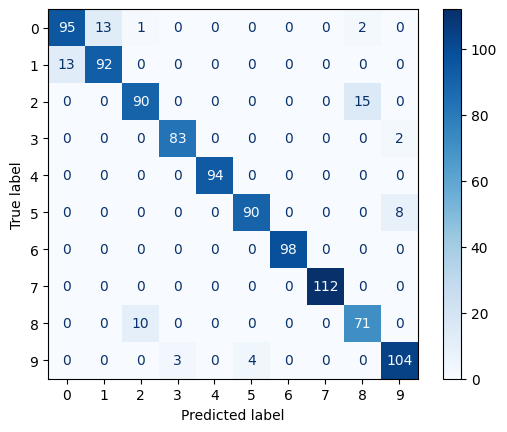

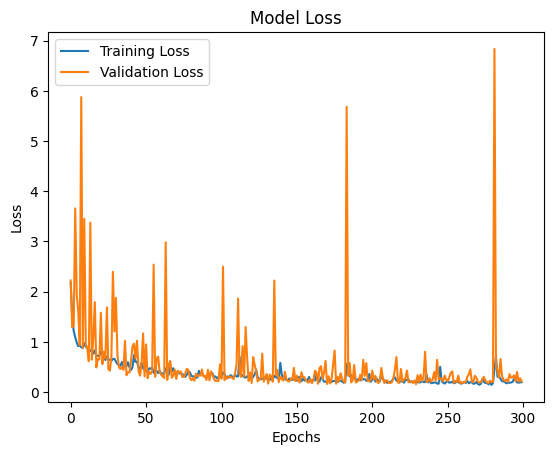

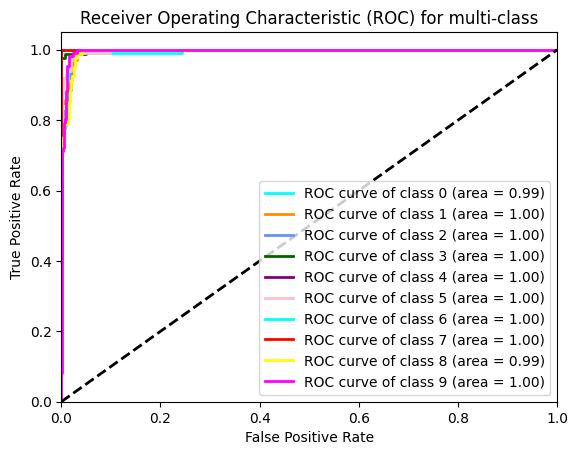

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.99
Class 9 AUC: 1.00


In [47]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=300, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('BB0116_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'BB0116_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 93.40%
Precision: 93.51%
Recall: 93.40%
F1 Score: 93.42%


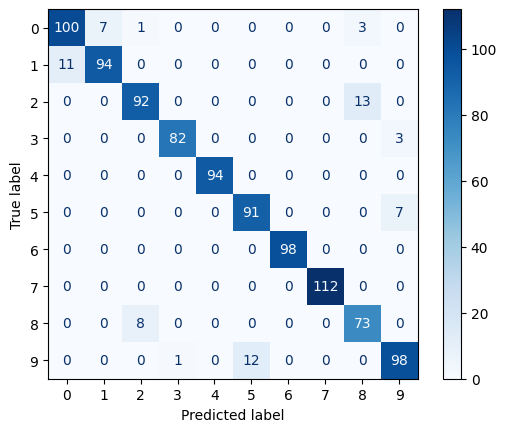

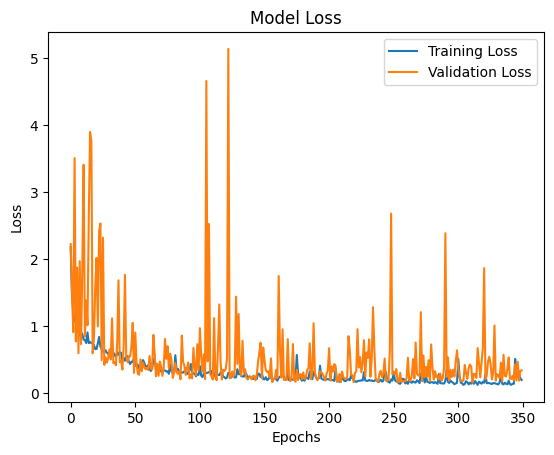

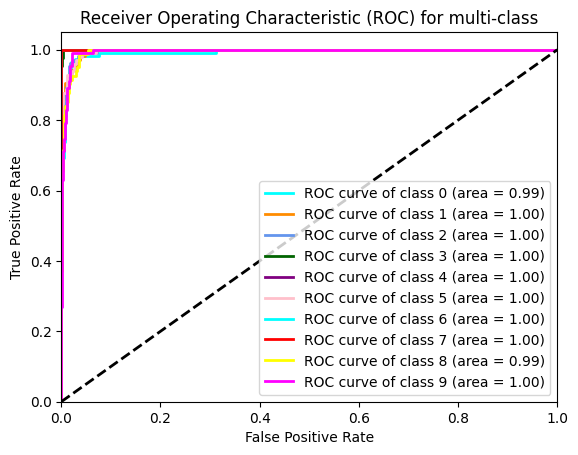

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.99
Class 9 AUC: 1.00


In [68]:

# Save the BiLSTM feature extractor model
model_feature_extractor.save('BB0116_bilstm_feature_extractor.h5')


# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=1, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'B2206_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300


2024-10-10 19:29:10.489924: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 127564800 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.1252 - loss: 2.9942 - val_accuracy: 0.1562 - val_loss: 2.2471
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.2404 - loss: 1.9672 - val_accuracy: 0.4112 - val_loss: 1.6855
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.3335 - loss: 1.5679 - val_accuracy: 0.3063 - val_loss: 1.4534
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4148 - loss: 1.2772 - val_accuracy: 0.2425 - val_loss: 2.3897
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4462 - loss: 1.2100 - val_accuracy: 0.3125 - val_loss: 2.4404
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4373 - loss: 1.1678 - val_accuracy: 0.2338 - val_loss: 2.0788
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4800 - loss: 1.0569 - val_accuracy: 0.2325 - val_loss: 2.8692
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5006 - loss: 1.0245 - val_accuracy

2024-10-10 19:46:40.761593: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 159456000 exceeds 10% of free system memory.


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


Accuracy: 87.40%
Precision: 87.64%
Recall: 87.40%
F1 Score: 87.44%


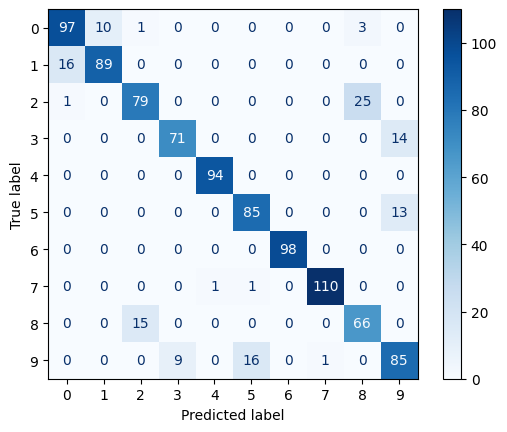

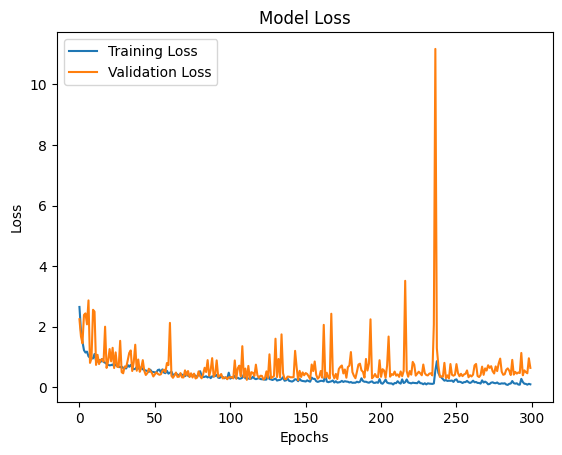

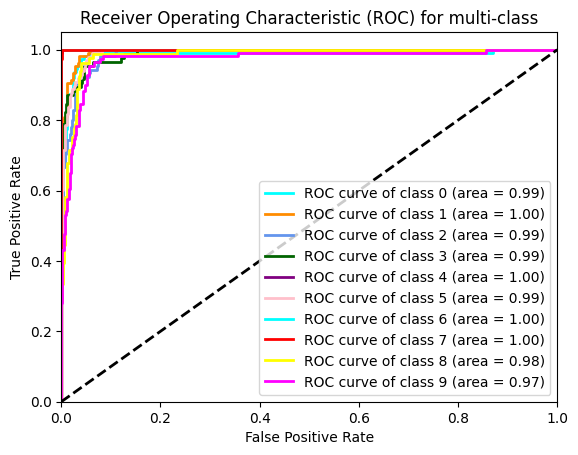

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 0.99
Class 3 AUC: 0.99
Class 4 AUC: 1.00
Class 5 AUC: 0.99
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 0.98
Class 9 AUC: 0.97


In [ ]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=300, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('B0116_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'B0116_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.1431 - loss: 2.6129 - val_accuracy: 0.1175 - val_loss: 2.1651
Epoch 2/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2434 - loss: 1.8421 - val_accuracy: 0.2362 - val_loss: 1.9458
Epoch 3/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3479 - loss: 1.5469 - val_accuracy: 0.4613 - val_loss: 1.2337
Epoch 4/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4081 - loss: 1.3171 - val_accuracy: 0.1112 - val_loss: 3.5689
Epoch 5/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4472 - loss: 1.1842 - val_accuracy: 0.4750 - val_loss: 1.0032
Epoch 6/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4791 - loss: 1.1438 - val_accuracy: 0.4225 - val_loss: 1.7290
Epoch 7/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4424 - loss: 1.1541 - val_accuracy: 0.5938 - val_loss: 0.8097
Epoch 8/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4721 - loss: 1.1355 - 

Accuracy: 95.70%
Precision: 95.81%
Recall: 95.70%
F1 Score: 95.72%


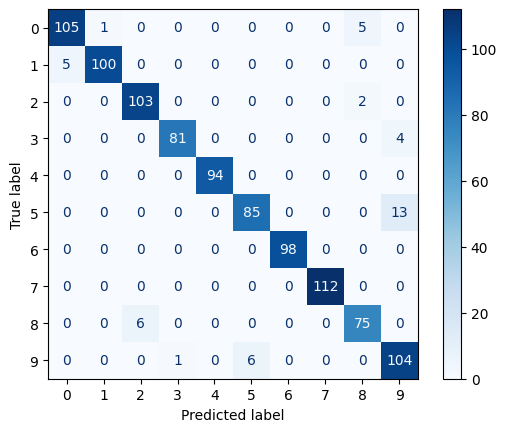

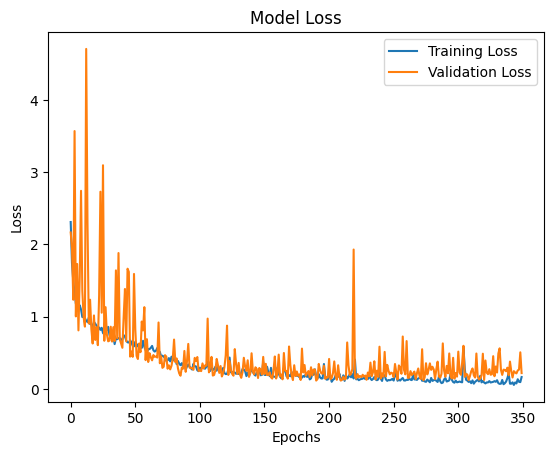

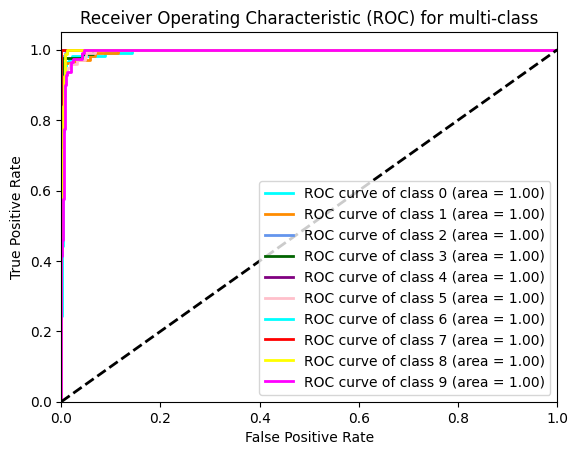

Class 0 AUC: 1.00
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [51]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=350, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('D0116_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'D0116_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/390


2024-09-28 06:44:27.382979: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 127564800 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.1337 - loss: 2.6784 - val_accuracy: 0.1225 - val_loss: 2.2254
Epoch 2/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2525 - loss: 1.8844 - val_accuracy: 0.2862 - val_loss: 1.6974
Epoch 3/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3252 - loss: 1.5874 - val_accuracy: 0.4462 - val_loss: 1.2232
Epoch 4/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3969 - loss: 1.3548 - val_accuracy: 0.1912 - val_loss: 1.8421
Epoch 5/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4414 - loss: 1.2109 - val_accuracy: 0.4475 - val_loss: 1.2269
Epoch 6/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4576 - loss: 1.1725 - val_accuracy: 0.3325 - val_loss: 1.8583
Epoch 7/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4647 - loss: 1.1337 - val_accuracy: 0.4988 - val_loss: 0.8824
Epoch 8/390
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4754 - loss: 1.0954 - val_accuracy

Accuracy: 96.60%
Precision: 96.69%
Recall: 96.60%
F1 Score: 96.62%


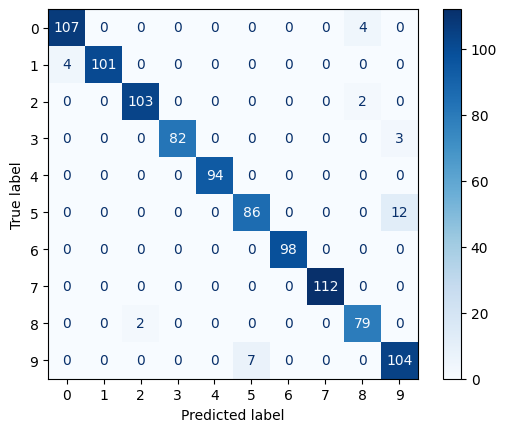

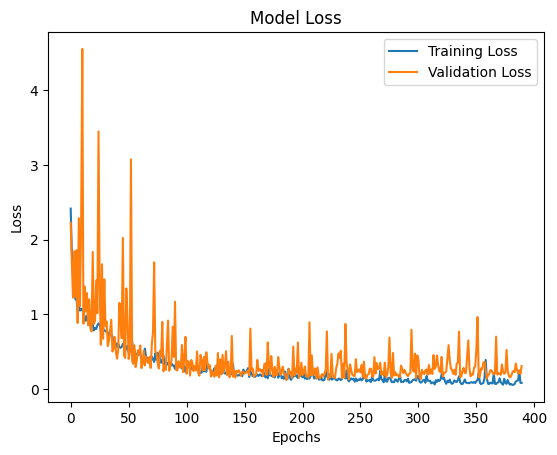

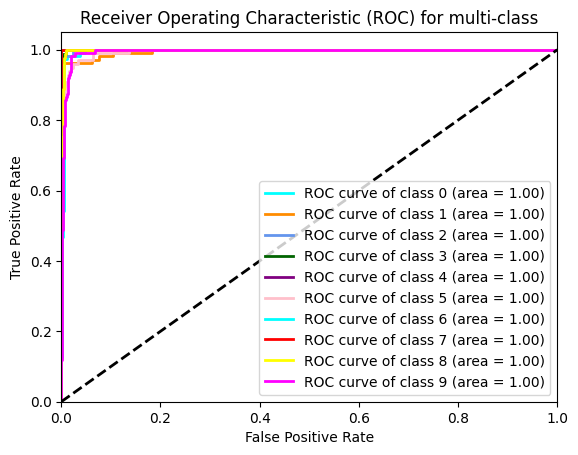

Class 0 AUC: 1.00
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 1.00


In [50]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=390, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('B0116_bilstm_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'B0116_xgboost2_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

In [88]:
# Reshape data for CNN input (samples, height, width, channels)
#n_samples, n_timesteps, n_features = data_spectrogram.shape
data_spectrogram = data_spectrogram.reshape(n_samples, n_timesteps, n_features, 1)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42)

In [53]:



# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n_timesteps, n_features, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
#model.add(Conv2D(128, (3, 3), activation='relu'))
##model.add(BatchNormalization())
#model.add(MaxPooling2D((2, 2)))
#model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=500, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=550, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('B1_200_cnn_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'B1_200_xgboost_cnn_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
  7/100 ━━━━━━━━━━━━━━━━━━━━ 26s 290ms/step - accuracy: 0.0946 - loss: 4.6980

100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 292ms/step - accuracy: 0.1575 - loss: 2.7741 - val_accuracy: 0.0950 - val_loss: 10.5146
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 292ms/step - accuracy: 0.2537 - loss: 1.7303 - val_accuracy: 0.0950 - val_loss: 17.6300
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 290ms/step - accuracy: 0.3280 - loss: 1.5171 - val_accuracy: 0.0950 - val_loss: 19.2554
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.3713 - loss: 1.3909 - val_accuracy: 0.0950 - val_loss: 15.3994
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 292ms/step - accuracy: 0.3604 - loss: 1.4139 - val_accuracy: 0.1250 - val_loss: 10.4346
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 286ms/step - accuracy: 0.4136 - loss: 1.3324 - val_accuracy: 0.2763 - val_loss: 2.7680
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 301ms/step - accuracy: 0.4009 - loss: 1.2991 - val_accuracy: 0.2412 - val_loss: 1.8888
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 293ms/step - accuracy: 0.4094 - loss: 

In [50]:


# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n_timesteps, n_features, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=500, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=300, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('200B_cnn_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, '200B_xgboost_cnn_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300


2024-09-27 23:03:34.546227: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 127564800 exceeds 10% of free system memory.


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 9966), dtype=float32). Expected shape (None, 33, 302, 1), but input has incompatible shape (32, 9966)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 9966), dtype=float32)
  • training=True
  • mask=None